In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from pre_processing import processed_img_preview, img_processing


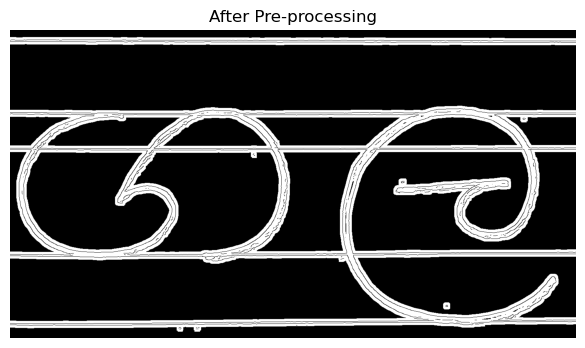

In [3]:
img = cv2.imread(IMAGE_PATH)

if img is None:
    raise ValueError("Image not found")

clean = img_processing(img)

plt.figure(figsize=(8,4))
plt.imshow(clean, cmap="gray")
plt.title("After Pre-processing")
plt.axis("off")
plt.show()


In [ ]:
def vertical_projection(binary_img):
    # sum white pixels column-wise
    return np.sum(binary_img > 0, axis=0)


In [ ]:
def smooth_projection(proj):
    # Savitzky–Golay smoothing
    return savgol_filter(proj, 21, 3)


In [ ]:
def find_split_points(proj, num_letters, margin_ratio=0.08):
    w = len(proj)

    # normalize
    proj = proj / np.max(proj)

    # ignore left & right margins
    left_margin = int(w * margin_ratio)
    right_margin = int(w * (1 - margin_ratio))

    threshold = 0.15
    candidates = np.where(
        (proj < threshold) &
        (np.arange(w) > left_margin) &
        (np.arange(w) < right_margin)
    )[0]

    gaps = []
    current = []

    for x in candidates:
        if not current or x == current[-1] + 1:
            current.append(x)
        else:
            gaps.append(current)
            current = [x]

    if current:
        gaps.append(current)

    # center of each gap
    centers = [int(np.mean(g)) for g in gaps]

    # choose best (num_letters - 1) gaps by width
    gaps_with_width = sorted(
        zip(gaps, centers),
        key=lambda x: len(x[0]),
        reverse=True
    )

    best_centers = sorted([c for _, c in gaps_with_width[:num_letters - 1]])

    return best_centers


In [ ]:
def split_by_vertical_projection(binary_img, num_letters):
    proj = vertical_projection(binary_img)
    proj_smooth = smooth_projection(proj)

    splits = find_split_points(proj_smooth, num_letters)

    h, w = binary_img.shape
    xs = [0] + splits + [w]

    letters = []
    for i in range(len(xs) - 1):
        part = binary_img[:, xs[i]:xs[i+1]]
        letters.append(part)

    return letters, proj_smooth, splits


In [ ]:
def preview_projection(binary_img, proj, splits):
    plt.figure(figsize=(10,3))
    plt.plot(proj)
    for s in splits:
        plt.axvline(s, color="red")
    plt.title("Vertical Projection + Split Points")
    plt.show()


In [ ]:
num_letters = 2

letters, proj, splits = split_by_vertical_projection(clean, num_letters)

preview_projection(clean, proj, splits)


In [ ]:
plt.figure(figsize=(12,3))

for i, l in enumerate(letters):
    plt.subplot(1, len(letters), i+1)
    plt.imshow(l, cmap="gray")
    plt.title(f"Letter {i+1}")
    plt.axis("off")

plt.suptitle(f"Split into {len(letters)} letters — NO CROP")
plt.tight_layout()
plt.show()


In [ ]:
def tight_crop(img):
    ys, xs = np.where(img > 0)
    if len(xs) == 0:
        return img
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1]


In [ ]:
cropped_letters = [tight_crop(l) for l in letters]

plt.figure(figsize=(12,3))
for i, l in enumerate(cropped_letters):
    plt.subplot(1, len(cropped_letters), i+1)
    plt.imshow(l, cmap="gray")
    plt.title(f"Cropped {i+1}")
    plt.axis("off")
plt.show()


In [ ]:
out_dir = "segmented_letters"
os.makedirs(out_dir, exist_ok=True)

for i, l in enumerate(cropped_letters):
    cv2.imwrite(f"{out_dir}/char_{i+1}.png", l)

print("Saved segmented letters to:", out_dir)
